In [9]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\KAN_variants")
from ChebyKANLayer import ChebyKAN

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\code")
from myKANODE import KANODE

In [10]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

# alpha, beta, delta, gamma
params = [1.5, 1, 2, 1]
X0 = [0.1, 0.2]

In [11]:
def vanDerPoll(X, t, epsilon):
    x = X[0]
    y = X[1]
    dxdt = y
    dydt = epsilon*(1-x*x)*y - x
    return [dxdt, dydt]
vdpX0 = [0, 1.5]
vdpParams = [0.2]

In [12]:
model = ChebyKAN([2, 10, 2], 4)
kanODE = KANODE(model, pred_prey_deriv, X0, params, 0.05, 7.5, 0.01)
saveDirectory = os.path.join(module_path, "savedModels", "lv-x0-[0.1, 0.2]")
kanODE.loadModel(saveDirectory, "defaultName 9941", loadOptimizer=False)

In [13]:
x, y = np.meshgrid(np.linspace(-3, 3, 40), np.linspace(-2, 6.5, 20))
x = x.flatten()
y = y.flatten()
coords = [[x[i],y[i]] for i in range(len(x))]

In [19]:
outputs = np.zeros([len(coords), 2])
trueOutputs = np.zeros([len(coords), 2])
for ii, coord in enumerate(coords):
    kanODE.setOdeIC(coord)
    _, solution = kanODE.test()
    vector = solution[-1] - solution[0]
    outputs[ii] = vector.detach().numpy()
    trueVector = kanODE.baseSolution[2] - kanODE.baseSolution[0]
    trueOutputs[ii] = trueVector


In [20]:
u = outputs[:, 0]
v = outputs[:, 1]
tu = trueOutputs[:, 0]
tv = trueOutputs[:, 1]

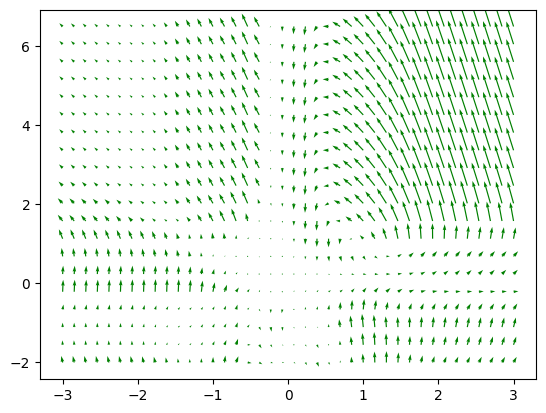

In [21]:
plt.quiver(x, y, u, v, color='g')

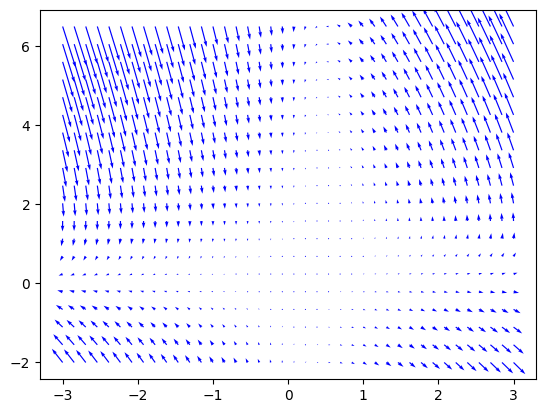

In [22]:
plt.quiver(x, y, tu, tv, color='b')